# Закупки группы Сбер за 2024–2025 годы
## Финальный аналитический отчёт
Отчёт объединяет сбор открытых данных, связывание источников, обезличивание, PostgreSQL, проверку гипотез, обнаружение аномалий, локальную Qwen и визуализации.

In [1]:
import json
from pathlib import Path
root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
out = root / 'data' / 'processed' / 'stage4'
stage2 = root / 'data' / 'processed' / 'stage2'
stage3 = root / 'data' / 'processed' / 'stage3'
conclusions = json.loads((out / 'conclusions.json').read_text(encoding='utf-8'))
summary = json.loads((out / 'stage4_summary.json').read_text(encoding='utf-8'))
summary


## Постановка задачи
Цель проекта — собрать и связать открытые сведения о закупках юридических лиц группы Сбер за 2024–2025 годы, очистить данные, спроектировать PostgreSQL, проверить аналитические гипотезы и подготовить воспроизводимый отчёт.

В основной аналитический слой включаются только процедуры, где заказчик или организатор подтверждён по ИНН. Простого упоминания слова «Сбербанк» в тексте недостаточно.

## Установка и кнопки запуска

Перед первым запуском необходимо установить Python 3.12 и выполнить `setup_environment.cmd`. Для базы устанавливается PostgreSQL 16. Для локального LLM устанавливаются Ollama и модель `qwen3.5:9b`.

| Файл | Назначение |
|---|---|
| `setup_environment.cmd` | Создание `.venv` и установка зависимостей |
| `start_project.cmd` | Единое меню проекта |
| `update_database.cmd` | Обновление PostgreSQL |
| `run_stage3_qwen.cmd` | Следующая порция Qwen |
| `run_stage4.cmd` | Пересбор финального отчёта |
| `open_notebook.cmd` | Открытие этого Notebook |

### Настройка Qwen

```powershell
ollama --version
ollama pull qwen3.5:9b
ollama list
.\run_stage3_qwen.ps1 -Limit 25
```

Результат каждой задачи записывается сразу, поэтому выполнение можно прерывать и продолжать.

## Рекомендуемый порядок запуска

```text
1. setup_environment.cmd
2. start_project.cmd
3. Пункт 7: Этапы 2, 3 и 4
4. Пункт 2: загрузка PostgreSQL
5. Пункт 4: Qwen при необходимости
6. Пункт 5: повторная сборка отчёта после Qwen
7. Пункт 6: открыть Jupyter
```

Сбор данных из интернета выполняется отдельно и занимает больше времени. Для демонстрации используются уже сохранённые обезличенные результаты.

## Источники данных

| Источник | Роль |
|---|---|
| Сбербанк-АСТ и SberB2B | Основной массив корпоративных процедур, даты, суммы, статусы и ссылки |
| ЕИС | Официальные карточки отдельных процедур 44-ФЗ и 223-ФЗ, независимая сверка |
| ФНС ЕГРЮЛ | Проверка ИНН, КПП, ОГРН и юридических наименований |
| ЗаказРФ, Росэлторг, ЛотОнлайн, ТЭК-Торг, РТС-тендер, ЭТП ГПБ | Проверка дополнительного покрытия |
| Банк России | Ежедневный USD/RUB и ключевая ставка |

Сбербанк-АСТ выбран основным источником из-за наибольшего числа подтверждённых процедур группы. ЕИС используется для межисточникового контроля. Остальные площадки входят в автоматический журнал проверки источников.

## Как собирались и обрабатывались данные

```text
Открытые площадки
        ↓
Поисковые результаты и карточки
        ↓
Проверка заказчика по реестру ИНН
        ↓
Связывание по точному номеру закупки
        ↓
Обогащение реквизитами ЕГРЮЛ
        ↓
Обезличивание ФИО, телефонов, почты, паспортов и СНИЛС
        ↓
Дедупликация и аналитический слой
        ↓
PostgreSQL, гипотезы, аномалии, LLM и графики
```

Удаление дублей выполняется только по точному идентификатору и подтверждённой связи источников. Текстовое сходство используется как сигнал для ручной проверки, но не как основание удаления.

## Описание собранных данных

- 17 проверенных организаций;
- 1 458 канонических закупок;
- 325 процедур за 2024 год;
- 1 133 процедуры за 2025 год;
- 1 461 строка источников;
- 3 точных межисточниковых дубля;
- 6 302 кандидата отделены от подтверждённой аналитики;
- сумма заполнена у 1 180 процедур;
- итоговая цена контракта в текущем слое отсутствует.

## Устройство PostgreSQL

Схема базы называется `sber_procurement`.

| Таблица | Зерно и назначение | Строк |
|---|---|---:|
| `organizations` | Одно юридическое лицо группы Сбер | 17 |
| `purchases` | Одна каноническая закупочная процедура | 1 458 |
| `purchase_sources` | Одно представление закупки на одной площадке | 1 461 |
| `purchase_candidates` | Один неподтверждённый поисковый результат | 6 302 |
| `duplicate_audit` | Одна подтверждённая связь дублирующих источников | 3 |
| `documents` | Одна карточка или вложение в очереди обработки | 1 461 |

```text
purchases
  ├── purchase_sources
  ├── duplicate_audit
  └── documents

organizations        purchase_candidates
```

Связь дочерних таблиц с закупкой выполняется через `canonical_purchase_id`. Индексы созданы по дате, ИНН заказчика, сумме и году/месяцу.

## Представления PostgreSQL

- `v_monthly_dynamics` — число закупок, сумма и медиана по месяцам;
- `v_customer_summary` — число и сумма закупок по заказчикам.

Структура создаётся файлом `stages/stage2/sql/schema.sql`, загрузка выполняется через `load_data.psql`.

## Примеры аналитических SQL-запросов

### Сравнение по годам

```sql
SELECT year,
       count(*) AS purchase_count,
       sum(amount_rub) AS total_amount_rub
FROM sber_procurement.purchases
GROUP BY year
ORDER BY year;
```

### Топ-20 закупок

```sql
SELECT purchase_number, customer_name, amount_rub, title
FROM sber_procurement.purchases
WHERE amount_rub IS NOT NULL
ORDER BY amount_rub DESC
LIMIT 20;
```

### Аудит дублей

```sql
SELECT duplicate_type, match_method, count(*)
FROM sber_procurement.duplicate_audit
GROUP BY duplicate_type, match_method;
```

### Закупки из нескольких источников

```sql
SELECT canonical_purchase_id,
       count(*) AS source_count,
       string_agg(source_system, ' | ' ORDER BY source_system)
FROM sber_procurement.purchase_sources
GROUP BY canonical_purchase_id
HAVING count(*) > 1;
```

Полный набор находится в `stages/stage2/sql/analytics_queries.sql`.

## Аналитические гипотезы

1. Сумма и количество IT-закупок связаны с USD/RUB.
2. Сумма и количество строительных закупок связаны с ключевой ставкой.
3. Крупнейшие процедуры существенно влияют на агрегированную сумму.
4. Рост количества публикаций и рост денежного объёма могут расходиться.

Для сумм применяется `log1p`. Коэффициент Пирсона проверяется перестановочным тестом на 10 000 перестановок. Уровень значимости — 0,05.

## Обнаружение аномалий

Проверяются экстремальные суммы, отмены, повторные публикации, конфликты статуса и скачки цены похожего предмета. Сигнал не является доказательством нарушения и используется только для приоритизации проверки карточек и документов.

## Динамика по месяцам
**Наблюдение:** Максимум количества пришёлся на 2025-11 (181 процедур), максимум суммы — на 2025-02 (413.6 млн руб.).  
**Интерпретация:** Рост во второй половине 2025 года может сочетать сезонность закупочного цикла и более полное покрытие площадки.  
**Значимость:** Месяцы-пики нельзя оценивать только по сумме: необходимо отделять массовую публикацию небольших процедур от единичных крупных лотов.  
**Ограничение:** Дата публикации не отражает дату оплаты или фактического исполнения контракта.

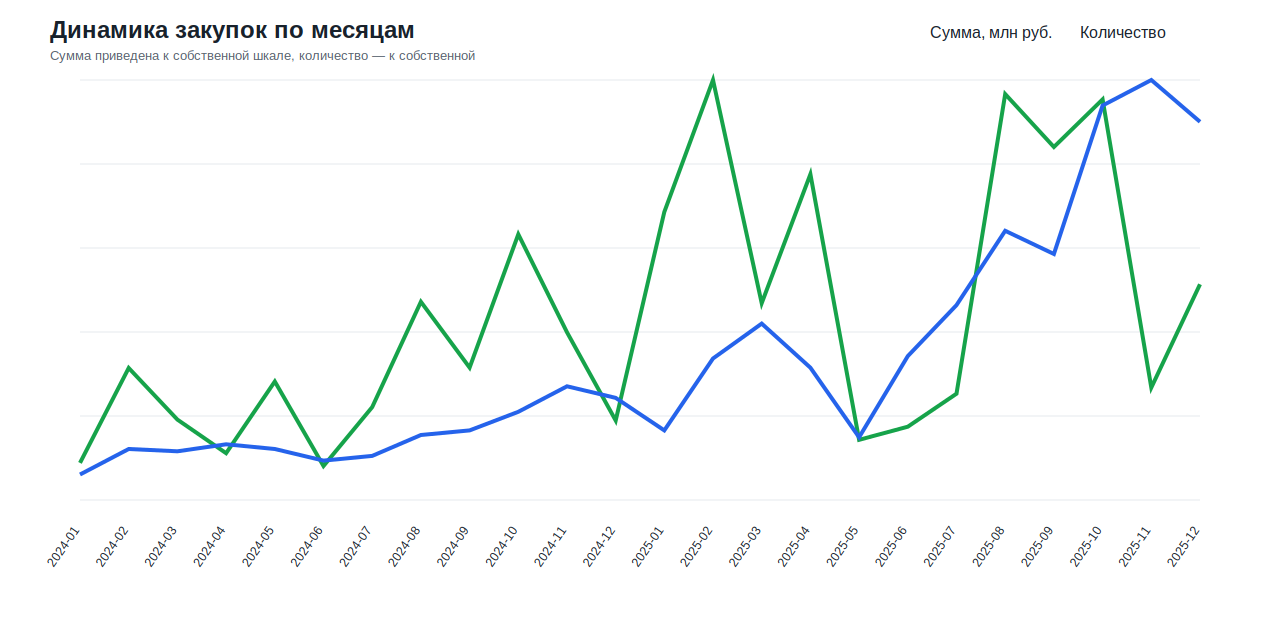

In [2]:
from IPython.display import SVG, display
display(SVG(filename=str(root / 'data' / 'processed' / 'stage4' / 'charts' / '01_monthly_dynamics.svg')))


## Структура направлений
**Наблюдение:** IT и телеком выросли с 61 до 149 процедур, указанная сумма — на 254.88%. Строительство выросло по количеству, но сумма изменилась на -5.24%.  
**Интерпретация:** Рост количества не всегда означает рост денежного объёма; структура и масштаб процедур меняются по-разному.  
**Значимость:** Направления необходимо сравнивать одновременно по количеству, сумме и медиане.  
**Ограничение:** Словарная классификация не заменяет ОКПД2 и проверку технических заданий.

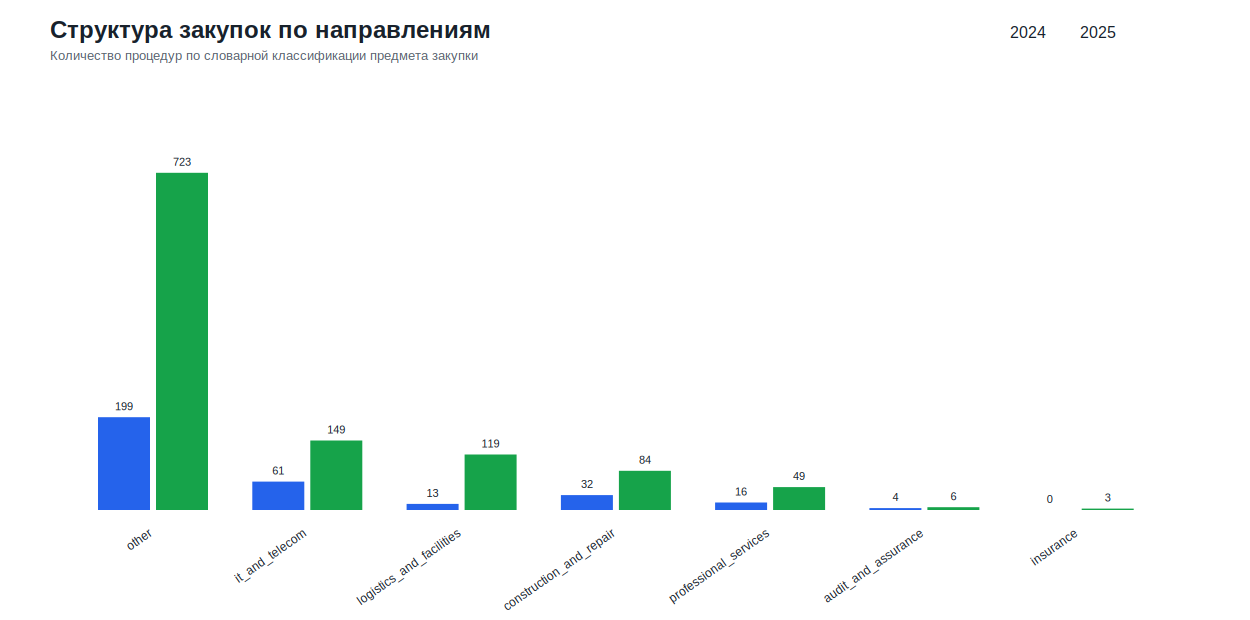

In [3]:
from IPython.display import SVG, display
display(SVG(filename=str(root / 'data' / 'processed' / 'stage4' / 'charts' / '02_category_structure.svg')))


## Топ-20
**Наблюдение:** Самая крупная процедура — SBR028-2502050031.1 на 296.1 млн руб.  
**Интерпретация:** Совокупная сумма чувствительна к небольшому числу крупных процедур.  
**Значимость:** Для устойчивых выводов следует показывать медиану и проводить анализ с исключением крупнейших наблюдений.  
**Ограничение:** Указанная сумма может быть НМЦ, лимитом, тарифом или единичной расценкой.

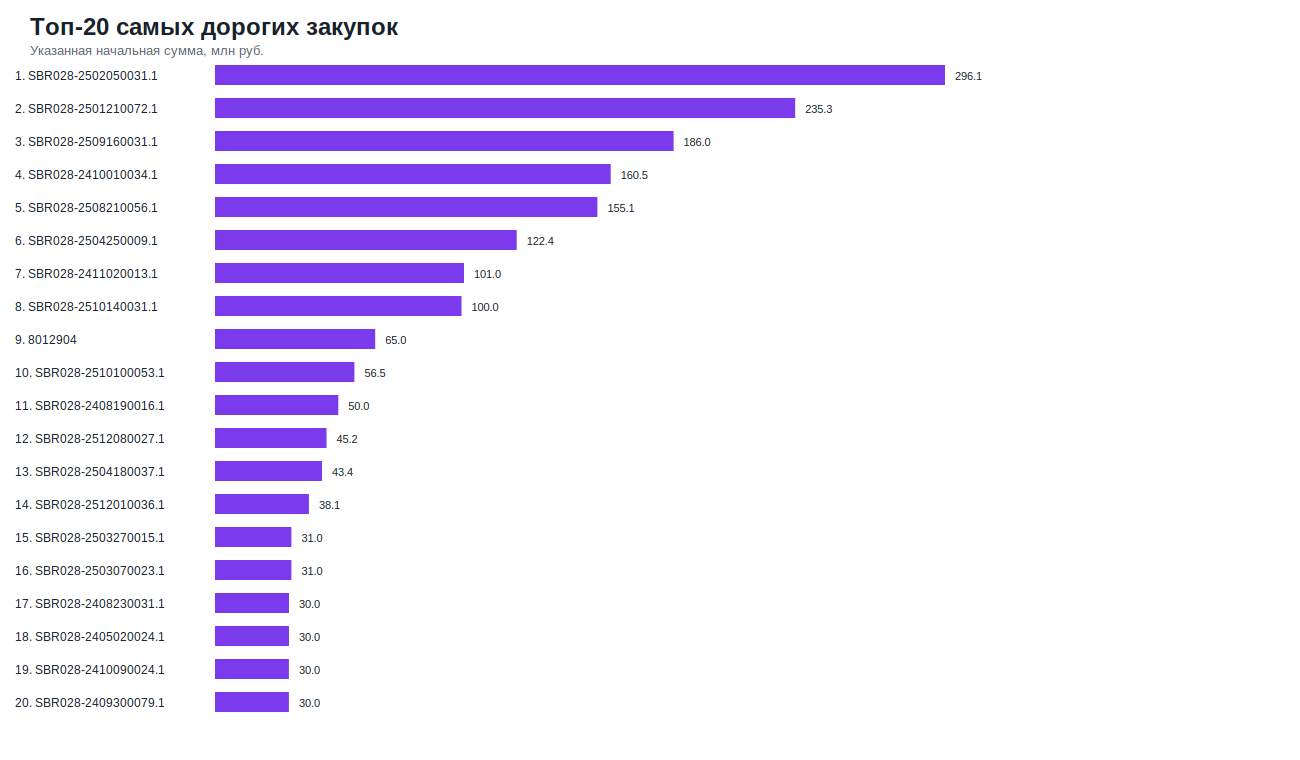

In [4]:
from IPython.display import SVG, display
display(SVG(filename=str(root / 'data' / 'processed' / 'stage4' / 'charts' / '03_top20_lots.svg')))


## IT и USD/RUB
**Наблюдение:** Для суммы IT-закупок связь незначима: r=-0.1039, p=0.6501. Для количества процедур получена отрицательная связь: r=-0.4957, p=0.0135.  
**Интерпретация:** Синхронная месячная сумма не следует за курсом; количество может отражать сезонность или изменение покрытия, а не прямой валютный эффект.  
**Значимость:** Статистическая проверка предотвращает ошибочный вывод по визуальному совпадению линий.  
**Ограничение:** Всего 24 месяца; не проверены лаги, сезонность и состав импортной компоненты.

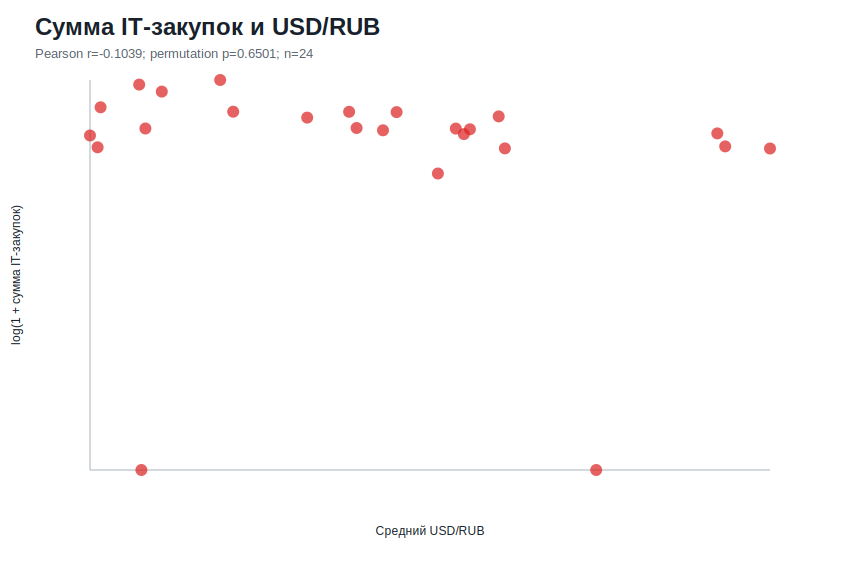

In [5]:
from IPython.display import SVG, display
display(SVG(filename=str(root / 'data' / 'processed' / 'stage4' / 'charts' / '04_it_vs_usd.svg')))


## Строительство и ключевая ставка
**Наблюдение:** Связь суммы строительных закупок с ключевой ставкой незначима: r=0.0134, p=0.951.  
**Интерпретация:** В пределах двух лет закупочная активность определяется не только стоимостью денег, но и бюджетами, проектными циклами и отдельными объектами.  
**Значимость:** Гипотеза не подтверждена текущей выборкой и не должна подаваться как установленная закономерность.  
**Ограничение:** Двадцать четыре наблюдения недостаточны для устойчивой модели с лагами и контролем сезонности.

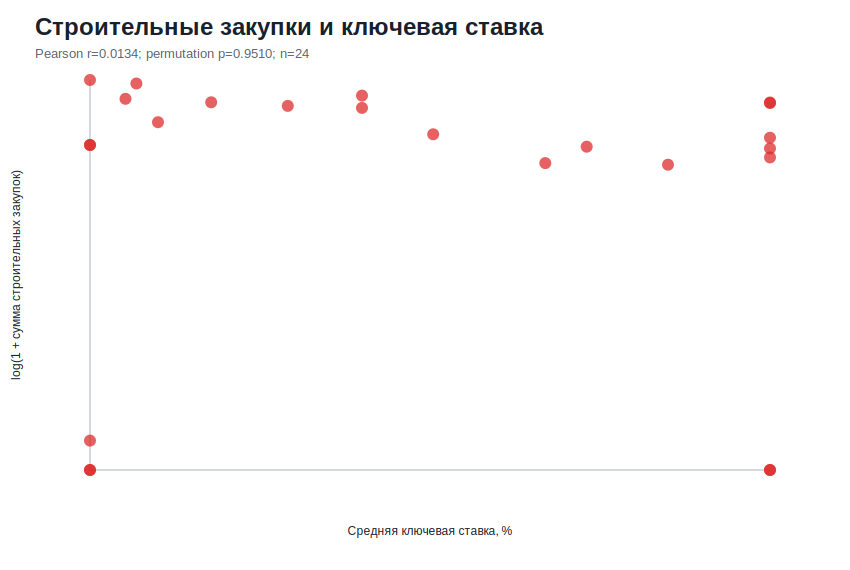

In [6]:
from IPython.display import SVG, display
display(SVG(filename=str(root / 'data' / 'processed' / 'stage4' / 'charts' / '05_construction_vs_key_rate.svg')))


## Распределение сумм
**Наблюдение:** Сумма отсутствует у 278 процедур; распределение охватывает диапазон от символических значений до лотов свыше 100 млн руб.  
**Интерпретация:** В одном поле смешаны разные экономические смыслы: полная НМЦ, тариф, единичная цена и незаполненное значение.  
**Значимость:** Среднее значение без очистки и сегментации будет вводить в заблуждение.  
**Ограничение:** Для нормализации нужны единица измерения, объём, тип цены и документы процедуры.

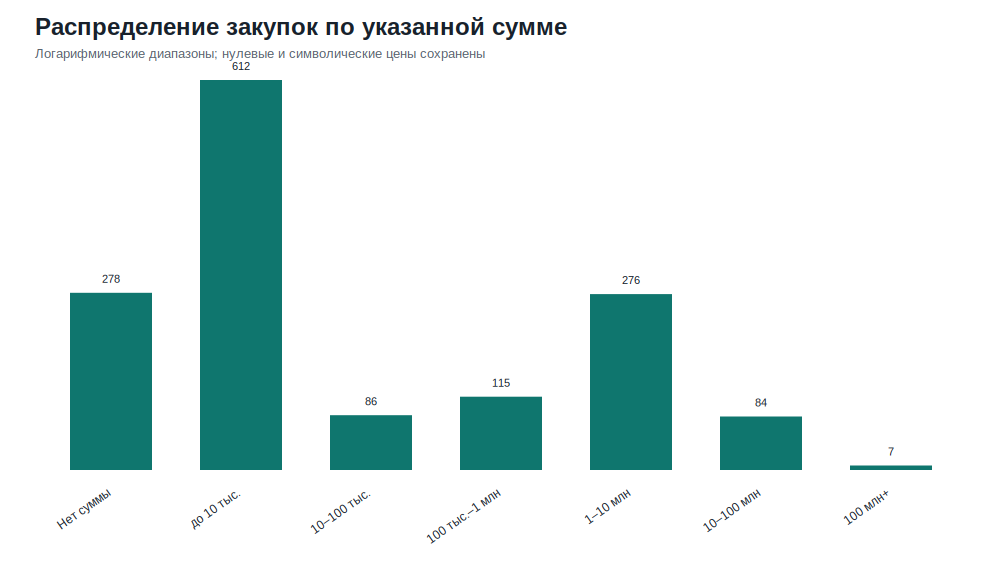

In [7]:
from IPython.display import SVG, display
display(SVG(filename=str(root / 'data' / 'processed' / 'stage4' / 'charts' / '06_amount_distribution.svg')))


## НМЦ → контракт
**Наблюдение:** Начальная сумма доступна у 1180 процедур, итоговая цена контракта — у 0.  
**Интерпретация:** Текущие поисковые карточки не содержат достаточного контрактного слоя.  
**Значимость:** Экономию, снижение цены и эффективность конкуренции нельзя рассчитывать без итоговой цены.  
**Ограничение:** Требуется извлечение протоколов, победителя, числа участников и суммы заключённого контракта.

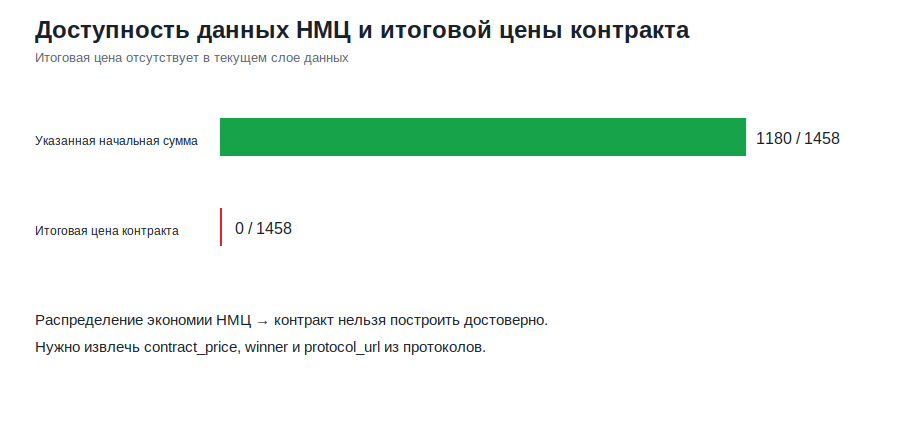

In [8]:
from IPython.display import SVG, display
display(SVG(filename=str(root / 'data' / 'processed' / 'stage4' / 'charts' / '07_nmc_contract_availability.svg')))


## LLM
**Наблюдение:** Qwen сформировала 38 валидных JSON из 38, но 26 ответов требуют ручной проверки формулировок.  
**Интерпретация:** Модель хорошо структурирует текст, но склонна усиливать риск-флаги до неподтверждённых предположений.  
**Значимость:** LLM полезна как черновик и инструмент приоритизации, а не как источник фактов о нарушениях.  
**Ограничение:** Обработано только 8,41% приоритетной очереди; выборка неслучайная.

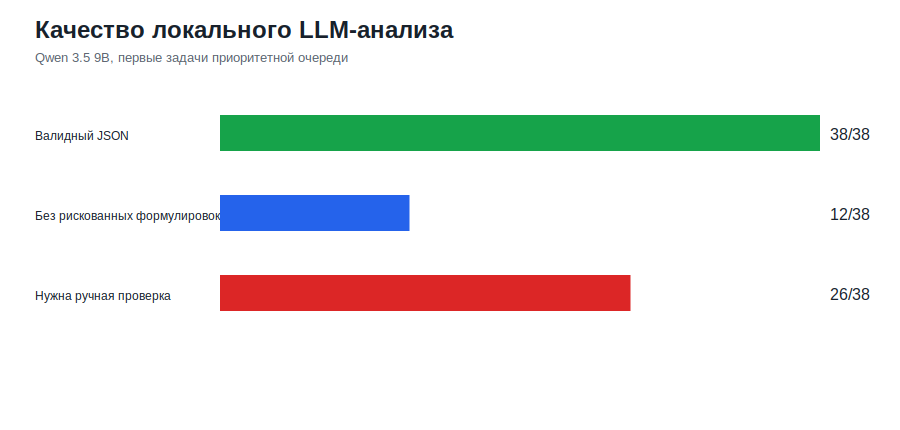

In [9]:
from IPython.display import SVG, display
display(SVG(filename=str(root / 'data' / 'processed' / 'stage4' / 'charts' / '08_llm_quality.svg')))


## Роль локальной Qwen

Qwen 3.5 9B запускается локально через Ollama. Модель формирует структурированный JSON и черновик вывода. Она не используется как источник фактов об участниках, победителях, единственном поставщике или нарушениях. Ответы проходят отдельный аудит рискованных формулировок.

## Общий вывод

В 2025 году число подтверждённых публикаций и указанная сумма выше, однако часть различия может быть связана с покрытием источника. IT и телеком являются ключевым содержательным направлением. Связь суммы IT-закупок с USD/RUB не подтверждена, как и связь строительной суммы с ключевой ставкой. Агрегаты чувствительны к отдельным крупным процедурам и неоднородному смыслу поля суммы.

Для полноценного анализа конкуренции и экономии необходимо извлечь протоколы, число участников, победителя и итоговую цену контракта. LLM полезна для структурирования и приоритизации, но её риск-выводы требуют ручной проверки.

## Воспроизводимый запуск

```powershell
python stages\stage1\scripts\build_stage1_dataset.py
python stages\stage1\scripts\anonymize_exports.py
python stages\stage1\scripts\enrich_multisource.py
python stages\stage2\scripts\process_stage2.py
.\update_database.cmd
python stages\stage3\scripts\analyze_stage3.py
python stages\stage3\scripts\summarize_llm_results.py
python stages\stage4\scripts\build_stage4.py
```

Для демонстрации достаточно открыть этот Notebook, выполнить `Restart Kernel and Run All Cells`, а затем последовательно показать методологию, схему базы, SQL и графики.